--- Configuración del Modelo Logístico ---
Defina la población tope (Capacidad de carga K): 1000


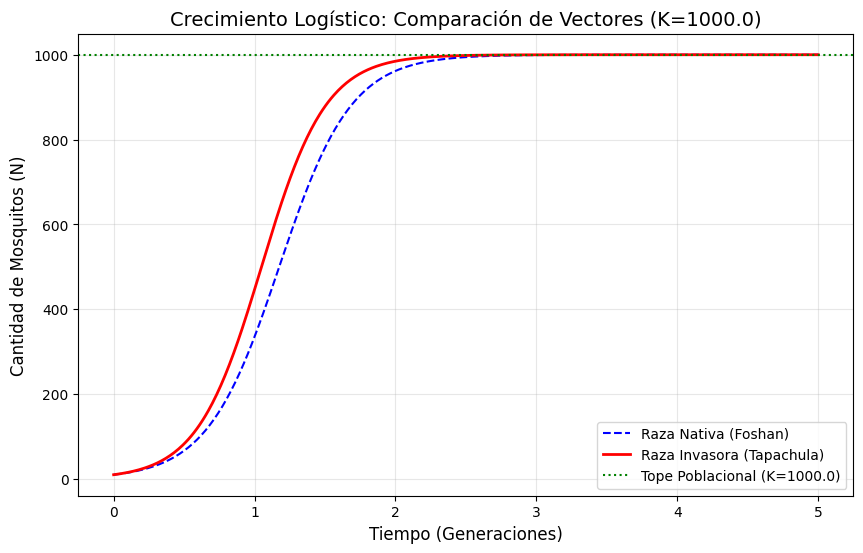

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PARÁMETROS BIOLÓGICOS (Fase 3: Datos Reales)
# ==========================================
r_n = 3.91  # Tasa raza Nativa (Foshan)
r_i = 4.38  # Tasa raza Invasora (Tapachula)
N0 = 10     # Población inicial de mosquitos

# ==========================================
# ENTRADA DE USUARIO (Capacidad de Carga)
# ==========================================
try:
    print("--- Configuración del Modelo Logístico ---")
    K_input = float(input("Defina la población tope (Capacidad de carga K): "))
except ValueError:
    print("Entrada no válida. Usando valor predeterminado K = 5000")
    K_input = 5000.0

# Definición del tiempo (Generaciones)
t = np.linspace(0, 5, 500)

# ==========================================
# MODELO LOGÍSTICO (Solución Continua Exacta)
# ==========================================
def modelo_logistico(N0, r, K, t):
    """
    Implementación de la solución exacta:
    X(t) = K / (1 + ((K - N0) / N0) * e^(-rt))
    """
    return K / (1 + ((K - N0) / N0) * np.exp(-r * t))

# Cálculo de las poblaciones
p_nativa = modelo_logistico(N0, r_n, K_input, t)
p_invasora = modelo_logistico(N0, r_i, K_input, t)

# ==========================================
# VISUALIZACIÓN (Matplotlib)
# ==========================================
plt.figure(figsize=(10, 6))

# Graficamos ambas razas con colores contrastantes
plt.plot(t, p_nativa, label='Raza Nativa (Foshan)', color='blue', linestyle='--')
plt.plot(t, p_invasora, label='Raza Invasora (Tapachula)', color='red', linewidth=2)
}
# Línea de referencia para el tope poblacional
plt.axhline(y=K_input, color='green', linestyle=':', label=f'Tope Poblacional (K={K_input})')

# Configuración de ejes y etiquetas
plt.title(f'Crecimiento Logístico: Comparación de Vectores (K={K_input})', fontsize=14)
plt.xlabel('Tiempo (Generaciones)', fontsize=12)
plt.ylabel('Cantidad de Mosquitos (N)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')

plt.show()